<a href="https://colab.research.google.com/github/TejshreeRameshKarande/Deep_Learning/blob/main/Experimet_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 18s 52ms/step - accuracy: 0.6855 - loss: 0.5713 - val_accuracy: 0.7890 - val_loss: 0.4554
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.8633 - loss: 0.3242 - val_accuracy: 0.7792 - val_loss: 0.4659
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 49ms/step - accuracy: 0.9245 - loss: 0.1959 - val_accuracy: 0.8314 - val_loss: 0.4824
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 21s 50ms/step - accuracy: 0.9782 - loss: 0.0672 - val_accuracy: 0.8070 - val_loss: 0.5907
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 48ms/step - accuracy: 0.9876 - loss: 0.0399 - val_accuracy: 0.7804 - val_loss: 0.7231
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 49ms/step - accuracy: 0.9944 - loss: 0.0199 - val_accuracy: 0.7998 - val_loss: 0.7684
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.9965 - loss: 0.0132 - val_accuracy: 0.7274 - val_loss: 0.9920
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - accuracy: 0.9912 - loss: 0.0249 - 

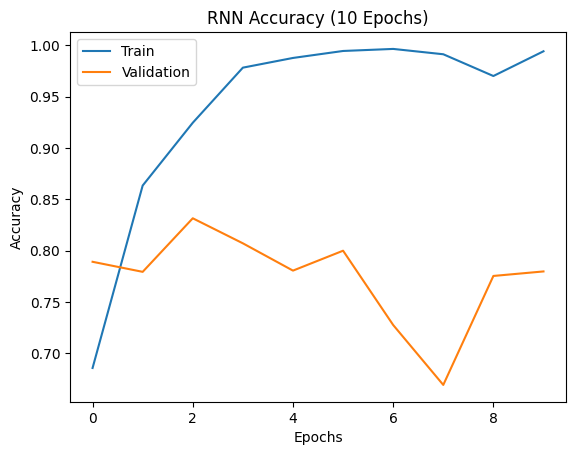

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Embedding

# Load data
vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# Padding
max_len = 200
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

# Model
model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    SimpleRNN(64),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train (UPDATED: epochs=10)
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

# Evaluate
loss, acc = model.evaluate(x_test, y_test)
print("RNN Accuracy:", acc)

# Predictions
predictions = model.predict(x_test)
for i in range(5):
    print(predictions[i][0], "->", "Positive" if predictions[i][0] > 0.5 else "Negative", "| Actual:", y_test[i])

# Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('RNN Accuracy (10 Epochs)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 145ms/step - accuracy: 0.7958 - loss: 0.4338 - val_accuracy: 0.8606 - val_loss: 0.3294
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 144ms/step - accuracy: 0.8992 - loss: 0.2576 - val_accuracy: 0.7936 - val_loss: 0.4193
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 46s 148ms/step - accuracy: 0.9323 - loss: 0.1835 - val_accuracy: 0.8456 - val_loss: 0.3807
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 80s 143ms/step - accuracy: 0.9456 - loss: 0.1508 - val_accuracy: 0.8680 - val_loss: 0.3656
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 144ms/step - accuracy: 0.9613 - loss: 0.1073 - val_accuracy: 0.8622 - val_loss: 0.4235
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 143ms/step - accuracy: 0.9599 - loss: 0.1082 - val_accuracy: 0.8532 - val_loss: 0.4902
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 144ms/step - accuracy: 0.9749 - loss: 0.0744 - val_accuracy: 0.8682 - val_loss: 0.5823
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 144ms/step - accuracy: 0.9806 - loss: 0

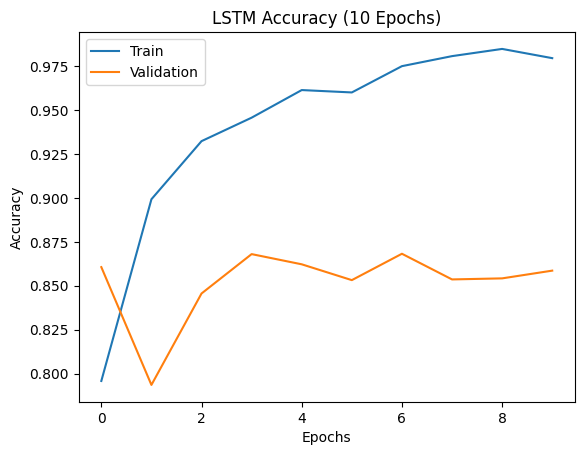

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Embedding

# Load data
vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# Padding
max_len = 200
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

# Model
model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    LSTM(64),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train (UPDATED: epochs=10)
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

# Evaluate
loss, acc = model.evaluate(x_test, y_test)
print("LSTM Accuracy:", acc)

# Predictions
predictions = model.predict(x_test)
for i in range(5):
    print(predictions[i][0], "->", "Positive" if predictions[i][0] > 0.5 else "Negative", "| Actual:", y_test[i])

# Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('LSTM Accuracy (10 Epochs)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 50s 154ms/step - accuracy: 0.7729 - loss: 0.4523 - val_accuracy: 0.8676 - val_loss: 0.3168
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 153ms/step - accuracy: 0.9017 - loss: 0.2491 - val_accuracy: 0.8664 - val_loss: 0.3196
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 152ms/step - accuracy: 0.9373 - loss: 0.1666 - val_accuracy: 0.8668 - val_loss: 0.3453
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 48s 153ms/step - accuracy: 0.9617 - loss: 0.1096 - val_accuracy: 0.8562 - val_loss: 0.4070
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 151ms/step - accuracy: 0.9724 - loss: 0.0799 - val_accuracy: 0.8660 - val_loss: 0.4510
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 150ms/step - accuracy: 0.9823 - loss: 0.0548 - val_accuracy: 0.8588 - val_loss: 0.5166
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 47s 151ms/step - accuracy: 0.9891 - loss: 0.0343 - val_accuracy: 0.8596 - val_loss: 0.5949
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 82s 151ms/step - accuracy: 0.9920 - loss: 0

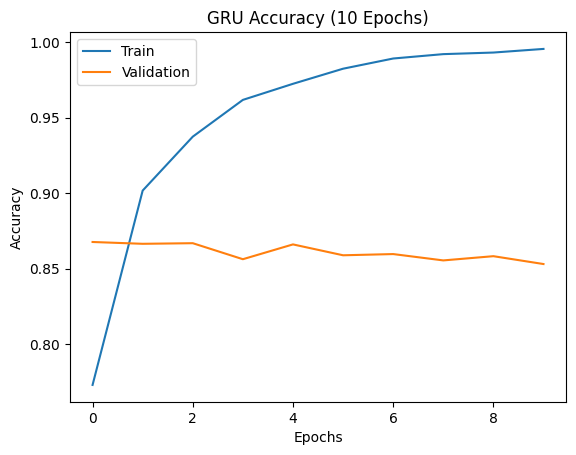

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Embedding

# Load data
vocab_size = 10000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

# Padding
max_len = 200
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

# Model
model = Sequential([
    Embedding(vocab_size, 128, input_length=max_len),
    GRU(64),
    Dense(1, activation='sigmoid')
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train (UPDATED: epochs=10)
history = model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

# Evaluate
loss, acc = model.evaluate(x_test, y_test)
print("GRU Accuracy:", acc)

# Predictions
predictions = model.predict(x_test)
for i in range(5):
    print(predictions[i][0], "->", "Positive" if predictions[i][0] > 0.5 else "Negative", "| Actual:", y_test[i])

# Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('GRU Accuracy (10 Epochs)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Train', 'Validation'])
plt.show()